# Temas Tratados en el Trabajo Práctico 3

* Estrategias de búsqueda local.

* Algoritmos Evolutivos.

* Problemas de Satisfacción de Restricciones.

# Ejercicios Teóricos

1. ¿Qué mecanismo de detención presenta el algoritmo de Ascensión de Colinas? Describa el problema que puede presentar este mecanismo y cómo se llaman las áreas donde ocurren estos problemas.

El algoritmo de Ascensión de Colinas es una técnica de búsqueda local voraz (greedy), por lo que toma decisiones basándose únicamente en la información de su entorno inmediato.
El algoritmo se detiene cuando evalúa a todos los vecinos inmediatos del estado actual y descubre que ninguno de ellos ofrece una mejora en el valor de la función de evaluación (fitness o costo). En ese punto, la regla de decisión concluye que ha alcanzado la cima del espacio de estados y detiene la búsqueda, devolviendo el estado actual como la solución.
El problema principal de este mecanismo es su falta de memoria y de visión global: al no recordar estados pasados ni poder explorar rutas que temporalmente empeoren la solución, el algoritmo queda atrapado en óptimos locales. El algoritmo "cree" erróneamente que ha encontrado la solución óptima global simplemente porque cualquier paso adicional hacia cualquier dirección parece ser peor, impidiéndole explorar otras zonas del espacio de estados donde podrían existir soluciones mucho mejores.
Areas donde ocurren estos problemas:
*Maximos locales*: Un pico o cima que es más alto que todos sus vecinos inmediatos, pero más bajo que el máximo global. Al llegar aquí, todos los vecinos son peores, por lo que el algoritmo se detiene sin alcanzar el verdadero óptimo.
*Mesetas*: Una región plana del espacio de estados donde varios estados vecinos consecutivos tienen exactamente el mismo valor de evaluación. El algoritmo pierde la dirección de gradiente (no sabe hacia dónde subir) y termina realizando un paseo aleatorio sin rumbo o deteniéndose prematuramente.
*Cresta o flechas*: Una secuencia de máximos locales orientada en diagonal dentro del espacio de estados. Debido a que las operaciones de movimiento del algoritmo suelen ser en direcciones ortogonales (un paso a la vez en una sola variable), cada vecino directo evaluado muestra un valor menor, haciendo que el algoritmo se detenga en la cresta a pesar de que existe un camino ascendente en diagonal.-m


2. Describa las distintas heurísticas que se emplean en un problema de Satisfacción de Restricciones.

1. Heurísticas para Selección de Variables
Deciden el orden en que se van a evaluar las variables del problema.

-VRM / MRV (Minimum Remaining Values - Valores Mínimos Restantes):

Mecanismo: Selecciona la variable no asignada que tiene la menor cantidad de valores posibles (los dominios más pequeños) en su dominio actual.

Propósito: Aplica el principio de "fallar primero" (fail-first). Si una variable tiene pocas opciones o está a punto de quedarse sin ninguna, conviene probarla de inmediato para detectar inconsistencias rápido y hacer backtracking antes de perder tiempo en otras ramas.

-Heurística del Grado (Degree Heuristic):

Mecanismo: Selecciona la variable que está involucrada en el mayor número de restricciones con otras variables que aún no han sido asignadas.

Propósito: Se utiliza generalmente como un desempate cuando MRV devuelve varias variables con la misma cantidad de valores en su dominio. Al elegir la variable más conectada, se imponen restricciones sobre la mayor cantidad posible de variables vecinas en el siguiente paso.

2. Heurísticas para Selección de Valores
Una vez que se ha elegido una variable, estas heurísticas deciden el orden en que se deben probar los valores de su dominio.

-LCV (Least Constraining Value - Valor Menos Restringido):

Mecanismo: Evalúa los valores del dominio de la variable elegida y selecciona aquel que elimine la menor cantidad de opciones en los dominios de las variables vecinas no asignadas.

Propósito: Aplica el principio de "suceder primero" (succeed-first). Busca dejar la mayor flexibilidad posible a las variables restantes para maximizar las probabilidades de encontrar una solución válida sin tener que volver atrás.

3. Se desea colorear el rompecabezas mostrado en la imagen con 7 colores distintos de manera que ninguna pieza tenga el mismo color que sus vecinas. Realice en una tabla el proceso de una búsqueda con Comprobación hacia Adelante empleando una heurística del Valor más Restringido.

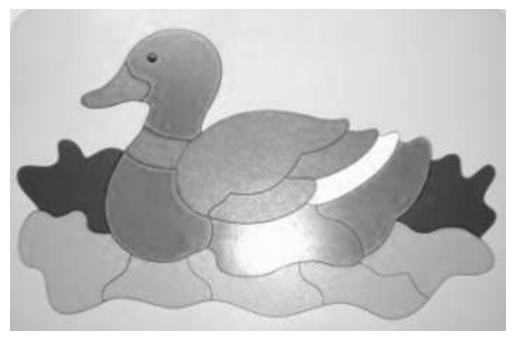

In [2]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1j94jFVxVG9y_ZnrMWOscQGb2MZ0Cdb3R"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

### Modelado del problema

El rompecabezas se modela como un **Problema de Satisfacción de Restricciones (CSP)**, que en
este caso es un problema clásico de **coloreo de grafos**:

- **Variables:** las 17 piezas del rompecabezas.
- **Dominio:** los 7 colores disponibles, $D = \{1,2,3,4,5,6,7\}$, igual para todas.
- **Restricciones:** binarias. Por cada par de piezas vecinas $(i, j)$ se exige
  $color_i \neq color_j$.

#### Numeración de las piezas

Como el enunciado no las numera, se asignó una numeración sobre la imagen:

| # | Pieza | # | Pieza |
|---|---|---|---|
| 1 | Pico | 10 | Costado / parte media |
| 2 | Cabeza | 11 | Arbusto izquierdo |
| 3 | Cuello (banda) | 12 | Arbusto derecho |
| 4 | Pecho / cuerpo delantero | 13 | Agua 1 (izquierda) |
| 5 | Cuerpo superior (lomo + base del ala) | 14 | Agua 2 |
| 6 | Ala pequeña (cobertora) | 15 | Agua 3 (centro) |
| 7 | Franja blanca (espéculo) | 16 | Agua 4 |
| 8 | Cola | 17 | Agua 5 (derecha) |
| 9 | Vientre | | |

#### Grafo de restricciones

Vecinas de cada pieza y su grado (cantidad de vecinas):

| Pieza | Vecinas | Grado | Pieza | Vecinas | Grado |
|---|---|---|---|---|---|
| 1 | 2 | 1 | 10 | 4, 5, 6, 7, 9 | 5 |
| 2 | 1, 3, 5 | 3 | 11 | 4, 13 | 2 |
| 3 | 2, 4, 5 | 3 | 12 | 8, 17 | 2 |
| 4 | 3, 5, 9, 10, 11, 13, 14, 15 | **8** | 13 | 4, 11, 14 | 3 |
| 5 | 2, 3, 4, 6, 9, 10 | 6 | 14 | 4, 13, 15 | 3 |
| 6 | 5, 7, 9, 10 | 4 | 15 | 4, 9, 14, 16 | 4 |
| 7 | 6, 8, 9, 10 | 4 | 16 | 9, 15, 17 | 3 |
| 8 | 7, 9, 12, 17 | 4 | 17 | 8, 12, 16 | 3 |
| 9 | 4, 5, 6, 7, 8, 10, 15, 16 | **8** | | | |

Las piezas 4 (pecho) y 9 (vientre) son las más conectadas, con 8 vecinas cada una.

### Metodología

#### Comprobación hacia Adelante (*Forward Checking*)

Es una forma de propagación de restricciones. Cada vez que se asigna un color a una pieza, se
**elimina ese color del dominio de todas sus vecinas todavía sin asignar**. Si alguna vecina se
queda con el dominio vacío, la asignación actual no puede llevar a ninguna solución y la rama se
descarta *en ese mismo momento*, sin seguir bajando por el árbol de búsqueda. Esa detección
temprana es lo que ahorra trabajo frente al backtracking cronológico simple, que recién
descubriría el conflicto al intentar colorear la pieza problemática.

#### Heurística del Valor más Restringido (MRV)

Determina **el orden en que se eligen las variables**. En cada paso se toma la pieza sin asignar
cuyo dominio sea el más chico, es decir, la que menos colores legales le quedan. La idea es
*"fallar primero"*: si una rama va a fracasar, conviene que fracase cuanto antes, cerca de la
raíz, para podar el subárbol más grande posible.

Como con 7 colores muchas piezas empatan en tamaño de dominio, se usan dos desempates:

1. **Heurística de grado:** gana la que tenga más vecinas aún sin asignar (es la que más poda al
   asignarse).
2. **Menor número de pieza:** desempate final, para que la traza sea reproducible.

Para el **orden de los valores** se prueba siempre el color legal más chico primero.

### Etapas de planeamiento y desarrollo

**Planeamiento**

1. **Modelar el rompecabezas como CSP** — reconocer que "ninguna pieza igual a sus vecinas" es
   exactamente un coloreo de grafos, y definir variables, dominios y restricciones.
2. **Construir el grafo de adyacencia** a partir de la imagen. Es el único dato que se carga a
   mano; el resto del problema se deduce de él.
3. **Elegir la estrategia de búsqueda:** backtracking con Comprobación hacia Adelante.
4. **Elegir el orden de variables:** heurística MRV, con desempate por grado.
5. **Definir la salida:** dos tablas, una con las decisiones tomadas y otra con la evolución de
   los dominios, más un dibujo del resultado.

**Desarrollo** (celda siguiente, sección por sección)

1. `PIEZAS`, `ADY` y `simetrizar()` — definición del CSP; `simetrizar()` garantiza que el grafo
   sea consistente en ambos sentidos.
2. `dominios_iniciales()` — cada pieza arranca con los 7 colores.
3. `seleccionar_variable_mrv()` — implementa MRV y los dos desempates.
4. `forward_check()` — poda los dominios de las vecinas y avisa si alguno queda vacío.
5. `resolver_fc()` — la recursión que combina lo anterior y va registrando la traza paso a paso.
6. `filas_decisiones()`, `filas_dominios()` y `mostrar_tabla()` — arman las dos tablas pedidas a
   partir de esa traza.
7. `dibujar_solucion()` — grafica el grafo con cada pieza pintada de su color.
8. Ejecución y **verificación automática**: un `assert` recorre todas las aristas y confirma que
   ninguna pieza comparte color con una vecina.

In [ ]:
import matplotlib.pyplot as plt

# pandas solo se usa para que las tablas se vean prolijas; si no está instalado
# se imprimen igual, como texto alineado.
try:
    import pandas as pd
except ImportError:
    pd = None


# ---------------------------------------------------------------------------
# 1) DEFINICIÓN DEL CSP
# ---------------------------------------------------------------------------

# Nombre de cada pieza, según la numeración marcada sobre la imagen.
PIEZAS = {
    1:  "Pico",             2:  "Cabeza",           3:  "Cuello",
    4:  "Pecho",            5:  "Cuerpo superior",  6:  "Ala pequeña",
    7:  "Franja blanca",    8:  "Cola",             9:  "Vientre",
    10: "Costado",          11: "Arbusto izq.",     12: "Arbusto der.",
    13: "Agua 1",           14: "Agua 2",           15: "Agua 3",
    16: "Agua 4",           17: "Agua 5",
}

# Grafo de adyacencia: qué piezas se tocan con cuáles (leído de la imagen).
# Es el único dato "a mano" del problema; todo lo demás se deduce de acá.
ADY = {
    1:  [2],
    2:  [1, 3, 5],
    3:  [2, 4, 5],
    4:  [3, 5, 9, 10, 11, 13, 14, 15],
    5:  [2, 3, 4, 6, 9, 10],
    6:  [5, 7, 9, 10],
    7:  [6, 8, 9, 10],
    8:  [7, 9, 12, 17],
    9:  [4, 5, 6, 7, 8, 10, 15, 16],
    10: [4, 5, 6, 7, 9],
    11: [4, 13],
    12: [8, 17],
    13: [4, 11, 14],
    14: [4, 13, 15],
    15: [4, 9, 14, 16],
    16: [9, 15, 17],
    17: [8, 12, 16],
}

N_COLORES = 7                                   # dominio: colores 1..7
COLORES = list(range(1, N_COLORES + 1))


def simetrizar(ady):
    """Devuelve el grafo con todas las aristas en ambos sentidos.

    Así alcanza con escribir cada vecindad una sola vez y no queda el riesgo de
    que una pieza figure como vecina de otra pero no al revés.
    """
    g = {p: set(vs) for p, vs in ady.items()}
    for p, vecinos in ady.items():
        for v in vecinos:
            g.setdefault(v, set()).add(p)
    return {p: sorted(vs) for p, vs in sorted(g.items())}


VECINOS = simetrizar(ADY)


def dominios_iniciales():
    """Estado inicial: toda pieza puede tomar cualquiera de los 7 colores."""
    return {p: set(COLORES) for p in VECINOS}


# ---------------------------------------------------------------------------
# 2) HEURÍSTICA DEL VALOR MÁS RESTRINGIDO (MRV)
# ---------------------------------------------------------------------------

def seleccionar_variable_mrv(dominios, asignacion):
    """Elige la próxima pieza a colorear con la heurística MRV.

    Criterio principal: la pieza sin asignar cuyo dominio (colores que todavía
    son legales) sea el más chico. Es la más restringida, la que antes va a
    quedarse sin opciones, así que conviene resolverla primero.

    Desempates:
      1) heurística de grado: la que tenga más vecinas aún sin asignar,
      2) el número de pieza más chico, para que la traza sea reproducible.
    """
    candidatas = [p for p in VECINOS if p not in asignacion]

    def clave(p):
        grado_libre = sum(1 for v in VECINOS[p] if v not in asignacion)
        return (len(dominios[p]), -grado_libre, p)

    return min(candidatas, key=clave)


# ---------------------------------------------------------------------------
# 3) COMPROBACIÓN HACIA ADELANTE (FORWARD CHECKING)
# ---------------------------------------------------------------------------

def forward_check(pieza, color, dominios, asignacion):
    """Propaga la asignación `pieza = color` hacia sus vecinas.

    Le saca ese color del dominio a cada vecina todavía sin asignar. Si alguna
    vecina se queda sin ningún color posible, la rama es un callejón sin salida
    y se corta acá mismo, sin bajar un nivel más en la recursión: en eso
    consiste "mirar hacia adelante".

    Devuelve (nuevos_dominios, podas), o (None, podas) si algún dominio quedó
    vacío. `podas` es la lista de vecinas afectadas, para mostrarla en la tabla.
    """
    nuevos = {p: set(d) for p, d in dominios.items()}
    nuevos[pieza] = {color}
    podas = []

    for vecina in VECINOS[pieza]:
        if vecina in asignacion or color not in nuevos[vecina]:
            continue
        nuevos[vecina].discard(color)
        podas.append(vecina)
        if not nuevos[vecina]:
            return None, podas          # dominio vacío -> fallo temprano
    return nuevos, podas


# ---------------------------------------------------------------------------
# 4) BÚSQUEDA CON RETROCESO + FORWARD CHECKING
# ---------------------------------------------------------------------------

def resolver_fc(asignacion, dominios, traza):
    """Backtracking guiado por MRV y podado con Forward Checking.

    Registra en `traza` un diccionario por cada paso, con todo lo que después
    se vuelca en las dos tablas del enunciado.
    """
    if len(asignacion) == len(VECINOS):
        return asignacion                       # todas las piezas coloreadas

    pieza = seleccionar_variable_mrv(dominios, asignacion)
    dominio_pieza = sorted(dominios[pieza])

    for color in dominio_pieza:
        nuevos, podas = forward_check(pieza, color, dominios, asignacion)

        traza.append({
            "pieza": pieza,
            "dominio": dominio_pieza,
            "color": color,
            "podas": podas,
            "estado": "Falla (vecina sin colores)" if nuevos is None else "Ok",
            # foto de los dominios tras la poda, para la tabla de dominios
            "dominios": {p: sorted(d) for p, d in (nuevos or dominios).items()},
            "asignadas": set(asignacion) | ({pieza} if nuevos else set()),
        })

        if nuevos is None:
            continue                            # FC detectó el fallo: otro color

        asignacion[pieza] = color
        resultado = resolver_fc(asignacion, nuevos, traza)
        if resultado is not None:
            return resultado

        # Ningún descendiente funcionó: se deshace la asignación y se registra.
        del asignacion[pieza]
        traza.append({
            "pieza": pieza,
            "dominio": dominio_pieza,
            "color": color,
            "podas": [],
            "estado": "RETROCESO",
            "dominios": {p: sorted(d) for p, d in dominios.items()},
            "asignadas": set(asignacion),
        })

    return None                                 # ningún color sirvió


# ---------------------------------------------------------------------------
# 5) TABLAS DEL PROCESO
# ---------------------------------------------------------------------------

def mostrar_tabla(filas, titulo):
    """Muestra una lista de diccionarios como tabla (pandas si está, si no texto)."""
    print(f"\n{titulo}")
    if pd is not None:
        tabla = pd.DataFrame(filas).set_index("Paso")
        try:                                    # dentro de Jupyter: tabla HTML
            from IPython.display import display
            display(tabla)
        except ImportError:
            print(tabla.to_string())
        return tabla

    columnas = list(filas[0])
    encabezado = dict(zip(columnas, columnas))
    anchos = [max(len(str(f[c])) for f in filas + [encabezado]) for c in columnas]
    print("  ".join(c.ljust(a) for c, a in zip(columnas, anchos)))
    print("  ".join("-" * a for a in anchos))
    for f in filas:
        print("  ".join(str(f[c]).ljust(a) for c, a in zip(columnas, anchos)))
    return filas


def filas_decisiones(traza):
    """Tabla 1: una fila por decisión tomada durante la búsqueda."""
    filas = []
    for i, paso in enumerate(traza, start=1):
        p = paso["pieza"]
        filas.append({
            "Paso": i,
            "Pieza (MRV)": f"{p} {PIEZAS[p]}",
            "|Dom|": len(paso["dominio"]),
            "Dominio": "".join(str(c) for c in paso["dominio"]),
            "Color": paso["color"],
            "Vecinas podadas": ", ".join(str(v) for v in paso["podas"]) or "-",
            "Resultado": paso["estado"],
        })
    return filas


def filas_dominios(traza):
    """Tabla 2: cómo queda el dominio de cada pieza después de cada paso.

    Las piezas ya asignadas aparecen entre corchetes con su único color.
    """
    filas = []
    for i, paso in enumerate(traza, start=1):
        fila = {"Paso": i}
        for p in VECINOS:
            texto = "".join(str(c) for c in paso["dominios"][p])
            fila[str(p)] = f"[{texto}]" if p in paso["asignadas"] else texto
        filas.append(fila)
    return filas


# ---------------------------------------------------------------------------
# 6) DIBUJO DE LA SOLUCIÓN
# ---------------------------------------------------------------------------

# Posición aproximada de cada pieza sobre la figura, para que el grafo se
# parezca al rompecabezas y no a una maraña de líneas.
POS = {
    1:  (0.8, 6.4), 2:  (1.9, 6.8), 3:  (1.7, 5.5), 4:  (1.9, 4.2),
    5:  (4.0, 5.6), 6:  (5.7, 5.0), 7:  (6.3, 4.6), 8:  (7.5, 4.4),
    9:  (4.6, 3.6), 10: (4.4, 4.6), 11: (0.6, 4.5), 12: (8.7, 4.2),
    13: (0.7, 2.6), 14: (2.4, 2.3), 15: (4.3, 2.1), 16: (6.4, 2.3),
    17: (8.0, 2.8),
}

PALETA = ["#e6194b", "#3cb44b", "#4363d8", "#ffe119",
          "#f58231", "#911eb4", "#46f0f0"]


def dibujar_solucion(asignacion):
    """Dibuja el grafo de piezas con el color asignado a cada una."""
    fig, ax = plt.subplots(figsize=(11, 6))

    for p, vecinos in VECINOS.items():          # aristas = restricciones
        for v in vecinos:
            if p < v:
                ax.plot([POS[p][0], POS[v][0]], [POS[p][1], POS[v][1]],
                        color="#999999", lw=1, zorder=1)

    for p, (x, y) in POS.items():               # nodos = piezas
        ax.scatter(x, y, s=900, zorder=2,
                   color=PALETA[asignacion[p] - 1], edgecolors="black")
        ax.text(x, y, str(p), ha="center", va="center",
                fontsize=11, fontweight="bold", zorder=3)

    usados = len(set(asignacion.values()))
    ax.set_title(f"Coloreo del rompecabezas "
                 f"({usados} colores distintos usados de {N_COLORES})")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 7) EJECUCIÓN
# ---------------------------------------------------------------------------

traza = []
solucion = resolver_fc({}, dominios_iniciales(), traza)

orden = [str(p["pieza"]) for p in traza if p["estado"] == "Ok"]
print("Orden de asignación (MRV):", ", ".join(orden))
print("Pasos registrados:", len(traza),
      "| Retrocesos:", sum(1 for p in traza if p["estado"] == "RETROCESO"))

mostrar_tabla(filas_decisiones(traza),
              "TABLA 1 - Proceso de búsqueda (MRV + Forward Checking)")
mostrar_tabla(filas_dominios(traza),
              "TABLA 2 - Dominios de cada pieza tras cada paso")

print("\nSolución final:")
for p in sorted(solucion):
    print(f"  {p:2d} {PIEZAS[p]:<16} -> color {solucion[p]}")

# Verificación: ninguna pieza puede compartir color con una vecina.
for p, vecinos in VECINOS.items():
    for v in vecinos:
        assert solucion[p] != solucion[v], f"Conflicto entre {p} y {v}"
print("\nOK: ninguna pieza comparte color con sus vecinas.")

dibujar_solucion(solucion)

### Resultado y conclusión

El algoritmo encuentra una solución válida en **17 pasos, sin un solo retroceso**, usando
únicamente **4 de los 7 colores** disponibles:

| Pieza | Color | Pieza | Color | Pieza | Color |
|---|---|---|---|---|---|
| 1 Pico | 2 | 7 Franja blanca | 3 | 13 Agua 1 | 3 |
| 2 Cabeza | 1 | 8 Cola | 1 | 14 Agua 2 | 2 |
| 3 Cuello | 2 | 9 Vientre | 2 | 15 Agua 3 | 3 |
| 4 Pecho | 1 | 10 Costado | 4 | 16 Agua 4 | 1 |
| 5 Cuerpo superior | 3 | 11 Arbusto izq. | 2 | 17 Agua 5 | 3 |
| 6 Ala pequeña | 1 | 12 Arbusto der. | 2 | | |

**¿Por qué no hubo retrocesos?** Porque 7 colores son muchos para este rompecabezas. La pieza
más restringida en cada momento nunca llega a quedarse sin opciones: en la Tabla 2 se ve que el
dominio más chico que aparece es de 4 colores (paso 4, pieza 10), lejos del dominio vacío que
haría fallar a la Comprobación hacia Adelante. Con dominios tan holgados, la primera rama que
explora la búsqueda ya es la solución.

**¿Cuándo se ve trabajar al Forward Checking?** Bajando `N_COLORES`:

| Colores | ¿Solución? | Pasos | Retrocesos | Fallas detectadas por FC |
|---|---|---|---|---|
| 3 | **No existe** | 24 | 9 | 6 |
| 4 | Sí | 17 | 0 | 0 |
| 7 | Sí | 17 | 0 | 0 |

Con 3 colores el problema es directamente **insatisfacible**: las piezas 4, 5, 9 y 10 se tocan
todas entre sí (forman un $K_4$), así que necesitan 4 colores distintos sí o sí. Ahí se ve el
valor de la Comprobación hacia Adelante: detecta 6 de esos callejones sin salida *antes* de
seguir bajando en el árbol, en lugar de descubrirlos recién al intentar colorear la pieza
conflictiva.

En resumen, el mínimo de colores necesario para este rompecabezas es **4**, y la combinación
MRV + Forward Checking lo resuelve sin explorar una sola rama equivocada.

# Ejercicios de Implementación

4. Encuentre el máximo de la función $f(x) = \frac{\sin(x)}{x + 0.1}$ en $x \in [-10; -6]$ con un error menor a $0.1$ utilizando el algoritmo _hill climbing_.

--- RESULTADOS ---
Máximo Encontrado (Hill Climbing): x = -7.7000, f(x) = 0.13002
Máximo Real (Exacto):             x = -7.7236, f(x) = 0.13006
Error relativo en X:              0.30%
Error relativo en f(x):          0.03%


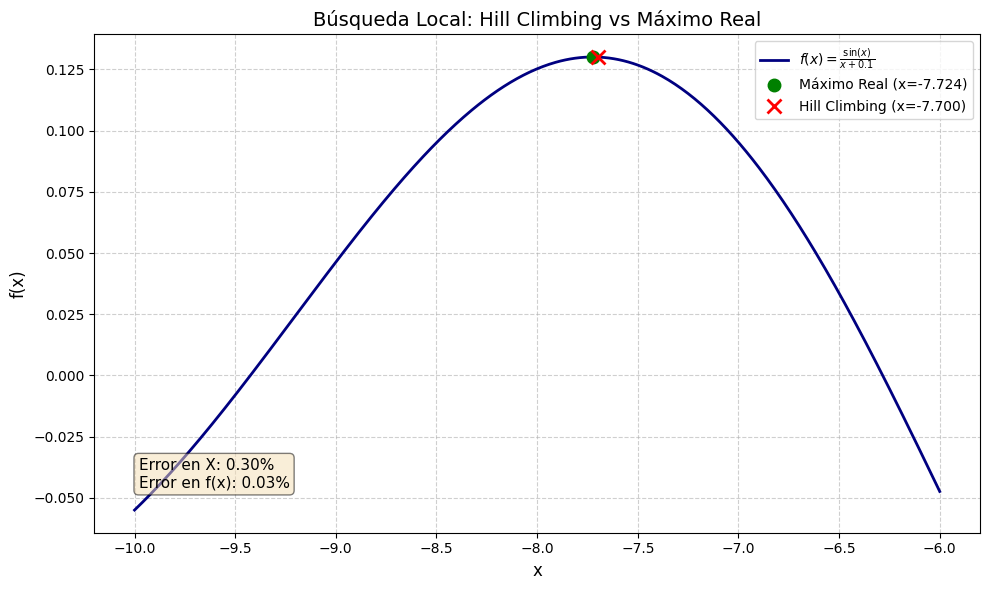

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize_scalar

# 1. Definición de la función
def f(x):
    return np.sin(x) / (x + 0.1)

# 2. Algoritmo Hill Climbing (Escalada de Colinas)
def hill_climbing(x_inicio, paso, limites):
    x_actual = x_inicio
    y_actual = f(x_actual)
    
    while True:
        # Evaluar vecinos
        x_izq = x_actual - paso
        x_der = x_actual + paso
        
        # Mantenerse dentro de los límites
        x_izq = max(limites[0], x_izq)
        x_der = min(limites[1], x_der)
        
        y_izq = f(x_izq)
        y_der = f(x_der)
        
        # Buscar la mejor dirección
        if y_izq > y_actual and y_izq >= y_der:
            x_actual = x_izq
            y_actual = y_izq
        elif y_der > y_actual and y_der > y_izq:
            x_actual = x_der
            y_actual = y_der
        else:
            # Se detiene cuando ningún vecino mejora la función
            break
            
    return x_actual, y_actual

# Parámetros del problema
limites = [-10.0, -6.0]
paso = 0.05
x_inicio = -10.0

# Ejecutar Hill Climbing
x_hc, y_hc = hill_climbing(x_inicio, paso, limites)

# 3. Cálculo del máximo real (Analítico/Numérico de alta precisión), se agrego como dato la comparacion con el valor real analitico para poder comparar
# Como minimize_scalar busca mínimos, minimizamos -f(x)
resultado = minimize_scalar(lambda x: -f(x), bounds=limites, method='bounded')
x_real = resultado.x
y_real = -resultado.fun

# 4. Cálculo del Porcentaje de Error
error_x = abs((x_hc - x_real) / x_real) * 100
error_y = abs((y_hc - y_real) / y_real) * 100

print(f"--- RESULTADOS ---")
print(f"Máximo Encontrado (Hill Climbing): x = {x_hc:.4f}, f(x) = {y_hc:.5f}")
print(f"Máximo Real (Exacto):             x = {x_real:.4f}, f(x) = {y_real:.5f}")
print(f"Error relativo en X:              {error_x:.2f}%")
print(f"Error relativo en f(x):          {error_y:.2f}%")

# 5. Generación del Gráfico
x_vals = np.linspace(limites[0], limites[1], 500)
y_vals = f(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label=r'$f(x) = \frac{\sin(x)}{x + 0.1}$', color='navy', linewidth=2)

# Marcar máximo real
plt.plot(x_real, y_real, 'go', markersize=9, label=f'Máximo Real (x={x_real:.3f})')

# Marcar máximo de Hill Climbing
plt.plot(x_hc, y_hc, 'rx', markersize=10, markeredgewidth=2, label=f'Hill Climbing (x={x_hc:.3f})')

# Detalle de anotación en el gráfico
plt.title('Búsqueda Local: Hill Climbing vs Máximo Real', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Caja con el resumen de errores
info_texto = f"Error en X: {error_x:.2f}%\nError en f(x): {error_y:.2f}%"
plt.gca().text(0.05, 0.15, info_texto, transform=plt.gca().transAxes, fontsize=11,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

5. Diseñe e implemente un algoritmo de Recocido Simulado para que juegue contra usted al Ta-te-ti. Varíe los valores de temperatura inicial entre partidas, ¿qué diferencia observa cuando la temperatura es más alta con respecto a cuando la temperatura es más baja?


6. Diseñe e implemente un algoritmo genético para cargar una grúa con $n=10\;cajas$ que puede soportar un peso máximo $C=1000\;kg$. Cada caja *j* tiene asociado un precio $p_j$ y un peso $w_j$ como se indica en la tabla de abajo, de manera que el algoritmo debe ser capaz de maximizar el precio sin superar el límite de carga.

<table><tr><td>Elemento ($j$)</td><td>1</td><td>2</td><td>3</td><td>4</td><td>5</td><td>6</td><td>7</td><td>8</td><td>9</td><td>10</td></tr>

<tr><td>Precio ($p_j$)</td><td>100</td><td>50</td><td>115</td><td>25</td><td>200</td><td>30</td><td>40</td><td>100</td><td>100</td><td>100</td></tr>

<tr><td>Peso ($w_j$)</td><td>300</td><td>200</td><td>450</td><td>145</td><td>664</td><td>90</td><td>150</td><td>355</td><td>401</td><td>395</td></tr></table><br>

        6.1 En primer lugar, es necesario representar qué cajas estarán cargadas en la grúa y cuáles no. Esta representación corresponde a un Individuo con el que trabajará el algoritmo.

        6.2 A continuación, genere una Población que contenga un número $N$ de individuos (se recomienda elegir un número par). Es necesario crear un control que verifique que ninguno de los individuos supere el peso límite.

        6.3 Cree ahora una función que permita evaluar la Idoneidad de cada individuo y seleccione $N/2$ parejas usando el método de la ruleta.

        6.4 Por último, Cruce las parejas elegidas, aplique un mecanismo de Mutación y verifique que los individuos de la nueva población no superen el límite de peso.

        6.5 Realice este proceso iterativamente hasta que se cumpla el mecanismo de detención de su elección y muestre el mejor individuo obtenido junto con el peso y el precio que alcanza.

## Resolución Punto 6 — Algoritmo Genético para cargar la grúa

El problema es una variante del **problema de la mochila 0‑1** (*knapsack*): hay que elegir un subconjunto de las 10 cajas que **maximice el precio total** sin que la suma de pesos supere la capacidad $C = 1000\;kg$.

Lo resolvemos con un **algoritmo genético (AG)** siguiendo el esquema visto en clase:

> población inicial aleatoria → evaluar **idoneidad** → **selección** (ruleta) → **cruce** → **mutación** → validar → repetir hasta que la población converja o se alcance un número de iteraciones, devolviendo el mejor individuo visitado.

**Parámetros configurables** (declarados al comienzo de la celda de código, se pueden cambiar libremente):

| Parámetro | Significado |
|---|---|
| `N_POBLACION` | tamaño de la población $N$ (debe ser **par**) |
| `PROB_MUTACION` | probabilidad de que cada gen (caja) mute |
| `MAX_GENERACIONES` | tope duro de iteraciones |
| `GEN_SIN_MEJORA` | parada anticipada si no mejora el mejor histórico |

**Qué va a mostrar la celda al final:**

1. Un **gráfico de la evolución del mejor fitness (precio) por generación**, junto con la curva del mejor histórico.
2. La **impresión del mejor individuo obtenido**: qué cajas carga, el **peso total** y el **precio total** alcanzado.

Toda la resolución está en **una única celda de código** a continuación, lista para ejecutar de un solo paso. Las secciones **6.1** a **6.5** quedan señaladas dentro de la celda con comentarios banner `# ===== 6.x =====`. Los comentarios marcados con `# [Apunte de clase]` reproducen (tal cual, con sus erratas) las ideas de las notas de la Clase 4 y se explican al lado con palabras propias.

In [ ]:
# ###########################################################################
# PUNTO 6 - ALGORITMO GENETICO PARA CARGAR LA GRUA  (TODO EN UNA SOLA CELDA)
# ###########################################################################
# Ejecutar esta unica celda resuelve el punto completo: 6.1 representacion,
# 6.2 poblacion, 6.3 fitness + ruleta, 6.4 cruce + mutacion, 6.5 iteracion y
# criterio de parada, y por ultimo el ploteo y la impresion de resultados.
# Las secciones estan separadas por banners "# ===== 6.x =====".


# ===========================================================================
# IMPORTS Y CONFIGURACION GLOBAL
# ===========================================================================
import numpy as np
import matplotlib.pyplot as plt
import random

# ---------------------------------------------------------------------------
# SEMILLA (control de la aleatoriedad)
# ---------------------------------------------------------------------------
# El AG es ESTOCASTICO: poblacion inicial, ruleta, punto de cruce y mutacion
# usan numeros aleatorios. Si se fija la semilla, esa secuencia aleatoria se
# repite identica en cada ejecucion (util para depurar / comparar), y por eso
# el resultado sale SIEMPRE igual.
#
#   SEED = None  ->  cada corrida usa una semilla distinta => resultado variable
#   SEED = 42    ->  corrida reproducible (siempre el mismo resultado)
SEED = None
if SEED is not None:
    np.random.seed(SEED)
    random.seed(SEED)

# ---------------------------------------------------------------------------
# DATOS DEL PROBLEMA (tabla del enunciado, en el mismo orden j = 1..10)
# ---------------------------------------------------------------------------
precios = np.array([100, 50, 115, 25, 200, 30, 40, 100, 100, 100])
pesos   = np.array([300, 200, 450, 145, 664, 90, 150, 355, 401, 395])

N_CAJAS = 10        # n = 10 cajas
C       = 1000      # capacidad maxima de la grua (kg)

# ---------------------------------------------------------------------------
# PARAMETROS AJUSTABLES DEL ALGORITMO GENETICO  (modificar libremente)
# ---------------------------------------------------------------------------
N_POBLACION      = 20      # N: tamano de la poblacion. DEBE SER PAR (ver 6.2).
PROB_MUTACION    = 0.05    # probabilidad de que cada gen (caja) mute (ver 6.4).
MAX_GENERACIONES = 100     # tope duro de iteraciones (criterio de parada, ver 6.5).
GEN_SIN_MEJORA   = 20      # parada anticipada: generaciones sin mejorar el mejor historico.

# [Apunte de clase] "Cada paso es una generacion de individuos. El tamano de la
# poblacion se mantiene constante (N)."  ->  en cada iteracion partimos de N
# individuos y volvemos a generar exactamente N hijos.
assert N_POBLACION % 2 == 0, "N_POBLACION debe ser par (cada pareja genera 2 hijos)."

print("Datos y parametros cargados:")
print("  precios :", precios)
print("  pesos   :", pesos)
print(f"  C = {C} kg | N = {N_POBLACION} | P(mut) = {PROB_MUTACION} | "
      f"max_gen = {MAX_GENERACIONES} | gen_sin_mejora = {GEN_SIN_MEJORA} | "
      f"SEED = {SEED}")


# ===========================================================================
# 6.1  REPRESENTACION DEL INDIVIDUO
# ===========================================================================
# Un individuo es un vector binario (numpy) de longitud N_CAJAS = 10:
#     gen j = 1  ->  la caja j viaja cargada en la grua
#     gen j = 0  ->  la caja j se queda afuera
#
# [Apunte de clase] "Cada individuo se representa como una cadena sobre un
# alfabeto finito (comunmente, una cadena de 0s y 1s)."  y en el ejemplo de las
# reinas  "Codificado por columna".  Aca la 'columna' es cada caja: el cromosoma
# tiene una posicion fija por caja y el alfabeto es {0, 1}.
#
# Ventaja de la representacion binaria: evaluar un individuo es un simple
# PRODUCTO PUNTO con los vectores de datos (operacion vectorial de numpy).

def peso(individuo):
    """Peso total (kg) de las cajas cargadas: producto punto con 'pesos'."""
    return int(np.dot(individuo, pesos))

def fitness(individuo):
    """Idoneidad = precio total: producto punto con 'precios'.
    [Apunte de clase] 'Una funcion de idoneidad deberia devolver valores mas
    altos para estados mejores'  ->  mas precio acumulado = mejor individuo."""
    return int(np.dot(individuo, precios))

def es_valido(individuo):
    """True si el individuo NO supera la capacidad C de la grua."""
    return peso(individuo) <= C

def cajas_de(individuo):
    """Lista de indices de caja (j = 1..10) que el individuo lleva cargados."""
    return (np.where(individuo == 1)[0] + 1).tolist()


# --- Ejemplo de la representacion: cajas 1, 3, 6 y 7 cargadas -------------
_demo = np.array([1, 0, 1, 0, 0, 1, 1, 0, 0, 0])
print("\n[6.1] Individuo demo :", _demo)
print("      Cajas cargadas :", cajas_de(_demo))
print("      Peso   =", peso(_demo), "kg")
print("      Precio = $", fitness(_demo), sep="")
print("      Valido =", es_valido(_demo))


# ===========================================================================
# 6.2  GENERACION DE LA POBLACION
# ===========================================================================
# [Apunte de clase] "genere una Poblacion que contenga un numero N de individuos
# (se recomienda elegir un numero par). Es necesario crear un control que
# verifique que ninguno de los individuos supere el peso limite."
#
# POR QUE N PAR: el operador de cruce toma PAREJAS de padres y devuelve 2 hijos
# por pareja. Con N par hay exactamente N/2 parejas -> N hijos, y asi la
# poblacion se mantiene constante generacion tras generacion
# ([Apunte de clase] "El tamano de la poblacion se mantiene constante (N)").
#
# CONTROL DE VALIDEZ: en lugar de descartar sin mas (podriamos quedarnos con muy
# pocos individuos si el azar genera muchos invalidos), usamos una REPARACION:
# mientras el individuo pese de mas, apagamos al azar una caja encendida. Es
# barata, SIEMPRE termina (en el peor caso deja el vector en 0, que pesa 0) y
# conserva aleatoriedad. Esta misma rutina se reutiliza en 6.4.

def reparar(individuo):
    """Devuelve una copia VALIDA del individuo: apaga cajas cargadas al azar
    hasta que el peso deje de superar la capacidad C."""
    ind = individuo.copy()
    while peso(ind) > C:
        encendidas = np.where(ind == 1)[0]      # posiciones de cajas cargadas
        apagar = np.random.choice(encendidas)   # elegimos una al azar
        ind[apagar] = 0                         # y la bajamos de la grua
    return ind

def crear_individuo_valido():
    """Individuo binario aleatorio (cadena de 0s y 1s) ya reparado."""
    ind = np.random.randint(0, 2, size=N_CAJAS)
    return reparar(ind)

def generar_poblacion(n):
    """Lista de n individuos validos. Exige n par (ver comentario de arriba)."""
    assert n % 2 == 0, "El tamano de poblacion debe ser par (2 hijos por pareja)."
    return [crear_individuo_valido() for _ in range(n)]


# --- Poblacion inicial + verificacion de que NINGUN individuo es invalido ---
poblacion_inicial = generar_poblacion(N_POBLACION)
assert all(es_valido(ind) for ind in poblacion_inicial), "Hay individuos invalidos!"

print(f"\n[6.2] Poblacion inicial: {len(poblacion_inicial)} individuos, todos validos.")
for k, ind in enumerate(poblacion_inicial):
    print(f"      #{k:02d}  {ind}  peso={peso(ind):4d} kg  precio=${fitness(ind):4d}")


# ===========================================================================
# 6.3  FUNCION DE IDONEIDAD (FITNESS) Y SELECCION POR RULETA
# ===========================================================================
# [Apunte de clase] Ejemplo de 8 reinas:
#   "Funcion idoneidad: numero de pares de reinas que no se atacan"
#   "24/(24+23+20+11) = 31%" , "23/(24+23+20+11) = 29%" , "Etc."
#   "En esta variante particular del AG, la probabilidad de ser elegido para la
#    reproduccion es directamente proporcional a la idoneidad."
#   "Como metodo de seleccion emplean el mecanismo de la ruleta."
#
# Idea de la RULETA: se suma el fitness de toda la poblacion y a cada individuo
# le corresponde una porcion de la ruleta proporcional a su fitness. Las
# porciones, normalizadas, suman 100%. Para armar una pareja se "gira la ruleta"
# dos veces.

def fitness_poblacion(poblacion):
    """Vector con el fitness (precio total) de cada individuo de la poblacion."""
    return np.array([fitness(ind) for ind in poblacion])


def probabilidades(fits):
    """Normaliza los fitness para que sumen 1 (equivale a los porcentajes de la
    ruleta: multiplicados por 100 dan 100%).
    Caso borde: si TODOS los fitness son 0, se reparte la ruleta en partes
    iguales para no dividir por cero."""
    total = fits.sum()
    if total == 0:
        return np.full(len(fits), 1.0 / len(fits))
    return fits / total


def seleccionar_parejas(poblacion, prob, n_parejas):
    """Devuelve una lista de n_parejas tuplas (padre1, padre2), elegidas por
    ruleta de forma totalmente aleatoria e independiente y ponderada por 'prob'.

    [Apunte de clase] "se seleccionan 2 pares, de manera aleatoria, para la
    reproduccion, de acuerdo con las probabilidades"  y  "Se puede notar que un
    individuo se selecciona 2 veces y uno ninguna."  ->  el sorteo es CON
    reposicion: NO se retira al individuo de la ruleta, por lo que uno bueno
    puede salir en varias parejas y uno malo puede no salir nunca.

    Regla adicional pedida en la consigna: un padre NO puede cruzarse consigo
    mismo. Si la ruleta devuelve el mismo indice para ambos padres, se vuelve a
    girar (no hace falta renormalizar: 'prob' ya suma 1). El fallback final
    cubre el caso degenerado en que casi toda la probabilidad este en un unico
    individuo: ahi se elige el segundo padre uniformemente entre los demas."""
    indices = np.arange(len(poblacion))
    parejas = []
    for _ in range(n_parejas):
        i = np.random.choice(indices, p=prob)      # primer padre (ponderado por fitness)
        j = np.random.choice(indices, p=prob)      # segundo padre (ponderado por fitness)
        intentos = 0
        while j == i and intentos < 100:           # evitar auto-cruce: re-sorteo
            j = np.random.choice(indices, p=prob)
            intentos += 1
        if j == i:                                 # caso degenerado: elegir otro al azar
            j = np.random.choice(indices[indices != i])
        parejas.append((poblacion[i], poblacion[j]))
    return parejas


# --- Demostracion de la ruleta sobre la poblacion inicial ----------------
_fits = fitness_poblacion(poblacion_inicial)
_prob = probabilidades(_fits)
print("\n[6.3] Fitness por individuo :", _fits)
print("      Porcentaje de ruleta  :", np.round(_prob * 100, 2))
print("      Suma de porcentajes   :", round(_prob.sum() * 100, 6), "%   (debe dar 100)")

_parejas_demo = seleccionar_parejas(poblacion_inicial, _prob, N_POBLACION // 2)
print(f"      Se armaron {len(_parejas_demo)} parejas (= N/2). Primeras 3:")
for a, b in _parejas_demo[:3]:
    print("       ", a, " x ", b)


# ===========================================================================
# 6.4  CRUCE (CROSSOVER DE UN PUNTO) Y MUTACION
# ===========================================================================

def cruce_un_punto(padre1, padre2):
    """CRUCE POR UN PUNTO. Se sortea una posicion de corte k (umbral) sobre el
    vector de 10 genes y se intercambian los tramos a cada lado de esa 'barrera'.

    [Apunte de clase] "El operador basico es el cruce por un punto: Se elige
    aleatoriamente un punto de la codificacion. Los descendientes se crean
    cruzando las cadenas paternales en el punto de cruce."  y  "En el ejemplo,
    el hijo consigue las dos primeras columnas del primer padre y las columnas
    restantes del segundo padre."

    En otras palabras, k funciona como una barrera que intercambia genes entre
    ambos padres:
        hijo1 = padre1[:k]  +  padre2[k:]
        hijo2 = padre2[:k]  +  padre1[k:]
    """
    k = np.random.randint(1, N_CAJAS)   # 1..9: asi ambos padres aportan algo
    hijo1 = np.concatenate([padre1[:k], padre2[k:]])
    hijo2 = np.concatenate([padre2[:k], padre1[k:]])
    return hijo1, hijo2


def mutar(individuo, prob=PROB_MUTACION):
    """MUTACION. A cada gen del nuevo individuo se le da una probabilidad 'prob'
    de mutar; mutar = invertir el bit (0->1 o 1->0).

    [Apunte de clase] "La mutacion consiste en cambiar el signo de cada bit (si
    se trata con una cadena binaria) con cierta probabilidad."  y  "A veces la
    informacion de parte de ellos cambia aleatoriamente."
    Sirve para inyectar diversidad y no quedar atrapados en optimos locales.
    La probabilidad es el parametro configurable PROB_MUTACION."""
    ind = individuo.copy()
    sorteo = np.random.random(N_CAJAS)   # un aleatorio U(0,1) independiente por gen
    flips = sorteo < prob                # mascara de los genes que mutan
    ind[flips] = 1 - ind[flips]          # flip 0<->1 sobre esos genes
    return ind


def descendencia(padre1, padre2):
    """Cruce + mutacion + VALIDACION de peso para una pareja. Devuelve 2 hijos
    validos.

    Validacion: despues de cruzar y mutar, un hijo puede pasarse de C kg. Se
    aplica la misma REPARACION que en 6.2 (apagar cajas al azar hasta cumplir).
    Se elige reparar en lugar de descartar para (a) no perder la combinacion
    genetica recien creada y (b) garantizar que la nueva poblacion tenga siempre
    exactamente N individuos validos."""
    h1, h2 = cruce_un_punto(padre1, padre2)
    h1 = reparar(mutar(h1))
    h2 = reparar(mutar(h2))
    return h1, h2


# --- Demostracion con la primera pareja sorteada en 6.3 -------------------
_p1, _p2 = _parejas_demo[0]
_h1, _h2 = descendencia(_p1, _p2)
print("\n[6.4] padre 1 :", _p1, " peso", peso(_p1))
print("      padre 2 :", _p2, " peso", peso(_p2))
print("      hijo  1 :", _h1, " peso", peso(_h1), " precio", fitness(_h1), " valido:", es_valido(_h1))
print("      hijo  2 :", _h2, " peso", peso(_h2), " precio", fitness(_h2), " valido:", es_valido(_h2))


# ===========================================================================
# 6.5  ITERACION Y CRITERIO DE PARADA
# ===========================================================================
# [Apunte de clase] "El procedimiento se itera hasta que la poblacion converge
# o pasa un numero especifico de iteraciones."  y del pseudocodigo de la clase:
# "{Devuelve el mejor S_act visitado}".
#
# CRITERIO DE PARADA ELEGIDO (cuantitativo, configurable arriba). Combinamos dos:
#   1) Tope duro: como maximo MAX_GENERACIONES iteraciones.
#   2) Parada anticipada por estancamiento: si pasan GEN_SIN_MEJORA generaciones
#      seguidas sin superar el mejor precio historico, se corta.
# Motivo: es un criterio simple y robusto que NO exige conocer de antemano el
# optimo del problema; el tope duro garantiza terminacion y el estancamiento
# evita gastar iteraciones cuando el AG ya convergio.
#
# EN CADA GENERACION SE GUARDA:
#   - historial_mejor_fitness : mejor precio de esa generacion (para el grafico)
#   - historial_global        : mejor precio historico acumulado (curva elitista)
#   - mejor_global            : el mejor individuo COMPLETO de toda la corrida
#                               (vector binario + peso + precio + generacion)
#
# CRITERIO DE "MEJOR SOLUCION ENCONTRADA" (mejor_global):
#   Es el individuo con el MAYOR fitness (= precio total) observado en CUALQUIER
#   generacion de toda la corrida. Todos los individuos son siempre validos
#   (peso <= C) porque se reparan, asi que basta maximizar el precio. Solo se
#   reemplaza cuando aparece uno ESTRICTAMENTE mejor (fits > mejor_global) -> si
#   hay empates, se conserva el primero que aparecio (y su nro de generacion).
# [Apunte de clase] Guardar el mejor historico es una forma de elitismo: aunque
# una generacion salga peor por azar, no perdemos la mejor solucion hallada.

def ejecutar_algoritmo_genetico(verbose=True):
    # Poblacion inicial (todos los individuos validos, ver 6.2)
    poblacion = generar_poblacion(N_POBLACION)

    historial_mejor_fitness = []   # mejor precio DENTRO de cada generacion
    historial_global = []          # mejor precio historico hasta cada generacion
    mejor_global = None            # dict con el mejor individuo de toda la corrida
    generaciones_sin_mejora = 0

    for gen in range(MAX_GENERACIONES):

        # ---- (1) EVALUACION DE IDONEIDAD de la poblacion actual -------------
        fits = fitness_poblacion(poblacion)
        prob = probabilidades(fits)                 # porciones de la ruleta

        # Mejor individuo de esta generacion
        idx_mejor = int(np.argmax(fits))
        mejor_gen = poblacion[idx_mejor]
        historial_mejor_fitness.append(int(fits[idx_mejor]))

        # ---- Actualizacion del MEJOR HISTORICO (elitismo) ------------------
        if mejor_global is None or fits[idx_mejor] > mejor_global["precio"]:
            mejor_global = {
                "individuo": mejor_gen.copy(),
                "peso": peso(mejor_gen),
                "precio": int(fits[idx_mejor]),
                "generacion": gen,
            }
            generaciones_sin_mejora = 0
        else:
            generaciones_sin_mejora += 1
        historial_global.append(mejor_global["precio"])

        if verbose and (gen % 10 == 0 or gen == MAX_GENERACIONES - 1):
            print(f"Gen {gen:3d} | mejor gen = {historial_mejor_fitness[-1]:4d} "
                  f"| mejor global = {mejor_global['precio']:4d} "
                  f"(peso {mejor_global['peso']} kg)")

        # ---- (2) CRITERIO DE PARADA por estancamiento ---------------------
        if generaciones_sin_mejora >= GEN_SIN_MEJORA:
            if verbose:
                print(f"\nParada anticipada en la generacion {gen}: "
                      f"{GEN_SIN_MEJORA} generaciones sin mejora.")
            break

        # ---- (3) SELECCION POR RULETA de N/2 parejas ----------------------
        parejas = seleccionar_parejas(poblacion, prob, N_POBLACION // 2)

        # ---- (4) CRUCE + MUTACION + VALIDACION -> nueva poblacion ---------
        # [Apunte de clase] "El tamano de la poblacion se mantiene constante (N)":
        # cada una de las N/2 parejas aporta 2 hijos => exactamente N individuos.
        nueva_poblacion = []
        for padre1, padre2 in parejas:
            h1, h2 = descendencia(padre1, padre2)   # cruce + mutacion + reparar
            nueva_poblacion.append(h1)
            nueva_poblacion.append(h2)
        poblacion = nueva_poblacion

    return mejor_global, historial_mejor_fitness, historial_global


# --- Corrida del algoritmo genetico ---------------------------------------
print("\n[6.5] Corrida del algoritmo genetico:")
mejor_global, historial_mejor_fitness, historial_global = ejecutar_algoritmo_genetico()

print("\nMejor solucion encontrada:")
print("  cromosoma :", mejor_global["individuo"])
print("  peso      :", mejor_global["peso"], "kg")
print("  precio    : $", mejor_global["precio"], sep="")


# ===========================================================================
# PLOTEO Y RESULTADOS FINALES
# ===========================================================================

gen_eje = np.arange(len(historial_mejor_fitness))

plt.figure(figsize=(9, 5))
# Curva 1: el mejor precio DENTRO de cada generacion (puede oscilar por el azar
# de la ruleta / mutacion, ya que no arrastramos el elitismo a la poblacion).
plt.plot(gen_eje, historial_mejor_fitness, marker="o", ms=3,
         label="Mejor de la generación")
# Curva 2: el mejor precio historico acumulado (elitismo) -> es monotona no
# decreciente y es el valor que finalmente devolvemos.
plt.plot(gen_eje, historial_global, lw=2,
         label="Mejor histórico (elitismo)")
plt.axhline(mejor_global["precio"], color="gray", ls="--", alpha=0.6,
            label=f"Óptimo del AG = ${mejor_global['precio']}")
plt.title("Evolución del mejor fitness (precio) por generación")
plt.xlabel("Generación")
plt.ylabel("Precio total [$]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Impresion clara del MEJOR INDIVIDUO FINAL: cajas, peso y precio
# ---------------------------------------------------------------------------
mejor = mejor_global["individuo"]
cajas_cargadas = cajas_de(mejor)   # indices de caja j = 1..10 que van en la grua

print("=" * 56)
print("MEJOR INDIVIDUO OBTENIDO POR EL ALGORITMO GENÉTICO")
print("=" * 56)
print("Cromosoma binario :", mejor)
print("Cajas cargadas    :", cajas_cargadas)
print("Detalle por caja  :")
for j in cajas_cargadas:
    print(f"   caja {j:2d}  ->  peso {pesos[j - 1]:4d} kg    precio ${precios[j - 1]:4d}")
print("-" * 56)
print(f"PESO TOTAL   : {mejor_global['peso']} kg     (límite C = {C} kg)")
print(f"PRECIO TOTAL : ${mejor_global['precio']}")
print(f"Encontrado en la generación : {mejor_global['generacion']}")
print(f"Restricción de capacidad respetada : {mejor_global['peso'] <= C}")

# Vectores/resultados quedan disponibles para inspeccion posterior:
#   mejor_global               -> dict con individuo / peso / precio / generacion
#   historial_mejor_fitness    -> lista: mejor precio de cada generacion
#   historial_global           -> lista: mejor precio historico por generacion


# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)